In [1]:
# BIBLIOTECAS
from google.colab import drive
import seaborn as sns
import matplotlib.pyplot as pl
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [4]:
# CARREGAR A BASE DE DADOS
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/Ap2-Data/global_cancer_patients - global_cancer_patients_2015_2024.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
df.head()

,Patient_ID,Age (20-89),Gender,Country_Region,Year,Genetic_Risk (0-10),Air_Pollution (0-10),Alcohol_Use (0-10),Smoking (0-10),Obesity_Level (0-10),Cancer_Type,Cancer_Stage,Treatment_Cost_USD,Survival_Years (0-10),Target_Severity_Score (0-10)
0,PT0000000,71,Male,UK,2021,6.4,2.8,9.5,0.9,8.7,Lung,Stage III,62913.44,5.9,4.92
1,PT0000001,34,Male,China,2021,1.3,4.5,3.7,3.9,6.3,Leukemia,Stage 0,12573.41,4.7,4.65
2,PT0000002,80,Male,Pakistan,2023,7.4,7.9,2.4,4.7,0.1,Breast,Stage II,6984.33,7.1,5.84
3,PT0000003,40,Male,UK,2015,1.7,2.9,4.8,3.5,2.7,Colon,Stage I,67446.25,1.6,3.12
4,PT0000004,43,Female,Brazil,2017,5.1,2.8,2.3,6.7,0.5,Skin,Stage III,77977.12,2.9,3.62


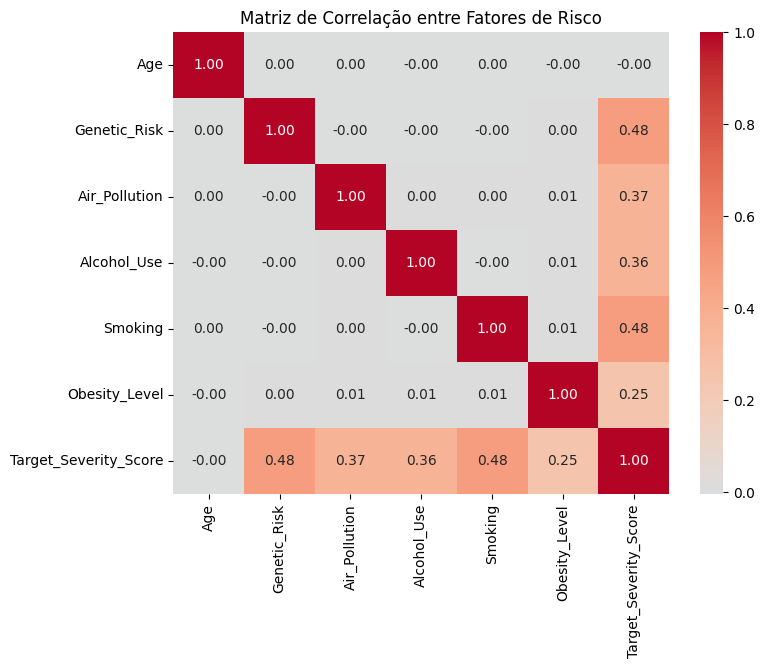

In [ ]:
# Variáveis numéricas utilizadas no modelo
num_cols = ['Age', 'Genetic_Risk', 'Air_Pollution',
            'Alcohol_Use', 'Smoking', 'Obesity_Level', 'Target_Severity_Score']

# Matriz de correlação com duas casas decimais
plt.figure(figsize=(8,6))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title('Matriz de Correlação entre Fatores de Risco')
plt.show()


Formato da base: (50000, 15)

Colunas: ['Patient_ID', 'Age', 'Gender', 'Country_Region', 'Year', 'Genetic_Risk', 'Air_Pollution', 'Alcohol_Use', 'Smoking', 'Obesity_Level', 'Cancer_Type', 'Cancer_Stage', 'Treatment_Cost_USD', 'Survival_Years', 'Target_Severity_Score']

Treino: (40000, 9)  | Teste: (10000, 9)
Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 2.6209 - mae: 0.9943 - val_loss: 0.3077 - val_mae: 0.4812
Epoch 2/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.3048 - mae: 0.4768 - val_loss: 0.3088 - val_mae: 0.4820
Epoch 3/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.3056 - mae: 0.4766 - val_loss: 0.3095 - val_mae: 0.4815
Epoch 4/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 0.3034 - mae: 0.4742 - val_loss: 0.3067 - val_mae: 0.4806
Epoch 5/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.3065 - mae: 0.4766 - val_loss: 0.3165 - val_mae: 0.4855
Epoch 6/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.3025 - mae: 0.4736 - val_loss: 0.3103 - val_mae: 0.4828
Epoch 7/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.3033 - mae: 0.4749 - val_loss: 0.3078 - val_mae: 0.4816
Epoch 8/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.3038 - mae: 0.4759 - val_loss: 0.3062 - val_mae: 0.4805
Epoch 9/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/st

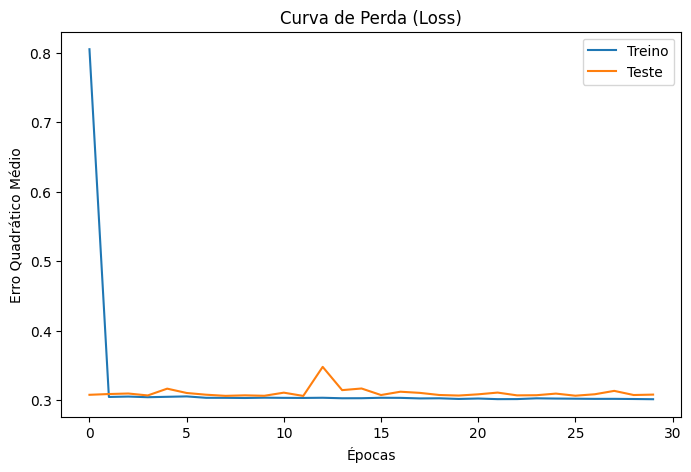

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


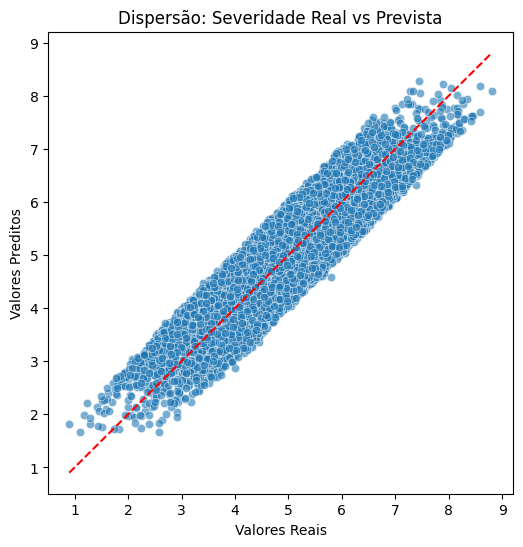

In [ ]:
# Verificar informações básicas
print("Formato da base:", df.shape)
print("\nColunas:", df.columns.tolist())
df.head()

# SELEÇÃO DAS VARIÁVEIS
# Variáveis numéricas e categóricas

# num_cols = ['Age','Genetic_Risk','Air_Pollution','Alcohol_Use','Smoking',
#              'Obesity_Level','Treatment_Cost_USD','Survival_Years']
# cat_cols = ['Gender','Country_Region','Cancer_Type','Cancer_Stage']


num_cols = ['Age','Genetic_Risk','Air_Pollution','Alcohol_Use','Smoking','Obesity_Level']
cat_cols = ['Gender']

# Variável alvo
target = 'Target_Severity_Score'

# 2 PRÉ-PROCESSAMENTO
# Codificar variáveis categóricas (One-Hot)
df_encoded = pd.get_dummies(df[cat_cols])

# Normalizar variáveis numéricas
scaler = MinMaxScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df[num_cols]), columns=num_cols)

# Unir dados tratados
X = pd.concat([df_scaled, df_encoded], axis=1)
y = df[target]

# Divisão treino/teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("\nTreino:", X_train.shape, " | Teste:", X_test.shape)

# CONSTRUÇÃO DO MODELO
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1, activation='linear')
])

model.compile(optimizer=Adam(learning_rate=0.001),
              loss='mean_squared_error',
              metrics=['mae'])


# TREINAMENTO
history = model.fit(X_train, y_train,
                    validation_data=(X_test, y_test),
                    epochs=30,
                    batch_size=32,
                    verbose=1)

# AVALIAÇÃO
results = model.evaluate(X_test, y_test, verbose=0)
print(f"\n Erro Médio Absoluto (MAE): {results[1]:.3f}")
print(f"Erro Quadrático Médio (MSE): {results[0]:.3f}")

# VISUALIZAÇÃO DO TREINAMENTO
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Treino')
plt.plot(history.history['val_loss'], label='Teste')
plt.title('Curva de Perda (Loss)')
plt.xlabel('Épocas')
plt.ylabel('Erro Quadrático Médio')
plt.legend()
plt.show()

# GRÁFICO DE VALORES REAIS vs PREDITOS
y_pred = model.predict(X_test).flatten()

plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.xlabel('Valores Reais')
plt.ylabel('Valores Preditos')
plt.title('Dispersão: Severidade Real vs Prevista')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()


🔍 10 Variáveis mais influentes na predição da severidade:

        Variável  Importância
1   Genetic_Risk     0.245801
4        Smoking     0.220482
3    Alcohol_Use     0.204204
2  Air_Pollution     0.194765
0            Age     0.193649
5  Obesity_Level     0.180052
7    Gender_Male     0.133580
8   Gender_Other     0.126781
6  Gender_Female     0.125604


/tmp/ipython-input-236005268.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance.head(10), x='Importância', y='Variável', palette='viridis')


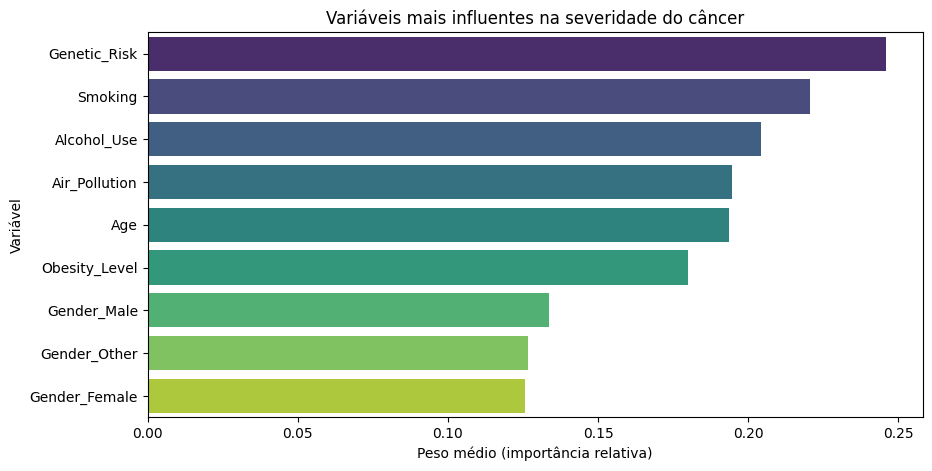

In [ ]:
#  Pegando os pesos da primeira camada da rede
pesos, bias = model.layers[0].get_weights()

# Cálculo da importância média absoluta de cada variável de entrada
importancia = np.mean(np.abs(pesos), axis=1)

# Criar DataFrame com as variáveis e seus pesos médios
feature_importance = pd.DataFrame({
    'Variável': X.columns,
    'Importância': importancia
}).sort_values(by='Importância', ascending=False)

# Exibir as 10 variáveis mais influentes
print("🔍 10 Variáveis mais influentes na predição da severidade:\n")
print(feature_importance.head(10))

# Gráfico de barras
plt.figure(figsize=(10,5))
sns.barplot(data=feature_importance.head(10), x='Importância', y='Variável', palette='viridis')
plt.title('Variáveis mais influentes na severidade do câncer')
plt.xlabel('Peso médio (importância relativa)')
plt.ylabel('Variável')
plt.show()


In [ ]:
# MÉTRICAS NO TREINO E NO TESTE

# Predições no conjunto de treino
y_train_pred = model.predict(X_train).flatten()

# Predições no conjunto de teste
y_test_pred = model.predict(X_test).flatten()

# Métricas do treino
mae_train = mean_absolute_error(y_train, y_train_pred)
mse_train = mean_squared_error(y_train, y_train_pred)
rmse_train = np.sqrt(mse_train)

# Métricas do teste
mae_test = mean_absolute_error(y_test, y_test_pred)
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = np.sqrt(mse_test)

print("===== MÉTRICAS DO TREINO =====")
print(f"MAE treino: {mae_train:.4f}")
print(f"MSE treino: {mse_train:.4f}")
print(f"RMSE treino: {rmse_train:.4f}")

print("\n===== MÉTRICAS DO TESTE =====")
print(f"MAE teste: {mae_test:.4f}")
print(f"MSE teste: {mse_test:.4f}")
print(f"RMSE teste: {rmse_test:.4f}")

# R² no treino e no teste
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

print("\n===== R² (TREINO E TESTE) =====")
print(f"R² treino: {r2_train:.4f}")
print(f"R² teste: {r2_test:.4f}")


1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 987us/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
===== MÉTRICAS DO TREINO =====
MAE treino: 0.4715
MSE treino: 0.2986
RMSE treino: 0.5464

===== MÉTRICAS DO TESTE =====
MAE teste: 0.4815
MSE teste: 0.3079
RMSE teste: 0.5549

===== R² (TREINO E TESTE) =====
R² treino: 0.7932
R² teste: 0.7833


In [ ]:
# Extrair ARQUITETURA
camadas = []
tipos = []
neuronios = []
ativacoes = []

for layer in model.layers:
    camadas.append(layer.name)
    tipos.append(layer.__class__.__name__)
    neuronios.append(layer.units if hasattr(layer, "units") else "—")
    ativacoes.append(layer.activation.__name__ if hasattr(layer, "activation") else "—")

tabela_modelo = pd.DataFrame({
    "Propriedade": ["Camada", "Tipo", "Neurônios", "Ativação"],
    "Valor": [camadas, tipos, neuronios, ativacoes]
})


# Extrair HIPERPARÂMETROS
learning_rate = model.optimizer.learning_rate.numpy()
loss_fn = model.loss

# Força a métrica final para MAE
metrica_final = "MAE"

epocas_treinadas = len(history.history['loss'])
batch_size = history.params.get('batch_size', "32")

total = len(X_train) + len(X_test)
divisao = f"{round(len(X_train)/total*100)}% / {round(len(X_test)/total*100)}%"


hiperparametros = pd.DataFrame({
    "Propriedade": [
        "Épocas",
        "Batch Size",
        "Otimizador",
        "Taxa de Aprendizado",
        "Função de Perda",
        "Métrica Monitorada",
        "Divisão Treino/Teste",
        "Normalização",
        "Codificação Categórica"
    ],
    "Valor": [
        epocas_treinadas,
        batch_size,
        type(model.optimizer).__name__,
        float(learning_rate),
        loss_fn,
        metrica_final,
        divisao,
        "MinMaxScaler (0 a 1)",
        "One Hot Encoding"
    ]
})


# 3. UNIR AS DUAS TABELAS
tabela_unica = pd.concat([tabela_modelo, hiperparametros], ignore_index=True)

print("Tabela Completa (Arquitetura + Hiperparâmetros):")
display(tabela_unica)


Tabela Completa (Arquitetura + Hiperparâmetros):


,Propriedade,Valor
0,Camada,"[dense, dense_1, dense_2]"
1,Tipo,"[Dense, Dense, Dense]"
2,Neurônios,"[64, 32, 1]"
3,Ativação,"[relu, relu, linear]"
4,Épocas,30
5,Batch Size,32
6,Otimizador,Adam
7,Taxa de Aprendizado,0.001
8,Função de Perda,mean_squared_error
9,Métrica Monitorada,MAE
